# Merge of all Dimensions (real-estate, commercial, social) into one dataframe ready for modeling

In [53]:
import pandas as pd 
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt

## Load Dataframes separately, Sanity Checks

In [45]:
#load dataframes re, c, s 
re_df = pd.read_csv("/Users/mareikesahling/Ginger_Gradient/Capstone/capstone-kiezkeeper/data/final_datasets/re_variables.csv",dtype={"plr_id": str})
c_df = pd.read_csv("/Users/mareikesahling/Ginger_Gradient/Capstone/capstone-kiezkeeper/data/final_datasets/feature_matrix_commercial_reduced.csv",dtype={"plr_id": str})
s_df = pd.read_csv("/Users/mareikesahling/Ginger_Gradient/Capstone/capstone-kiezkeeper/data/final_datasets/social_features.csv",dtype={"plr_id": str})

In [46]:
re_df.head()

,plr_id,plr_name,bez,re_miete_niveau,re_miete_trend,re_miete_unsicher,re_leerstandsquote,re_brw_niveau,re_brw_trend,re_brw_trend_outlier,...,re_dichte_all,re_baualter_unsicher,re_anteil_vor_1919,re_anteil_y1919_1948,re_anteil_y1949_1978,re_anteil_y1979_1990,re_anteil_y1991_2000,re_anteil_y2001_2010,re_anteil_y2011_plus,re_miet_dimension_anwendbar
0,01100101,Stülerstraße,01 - Mitte,22.70,2.142,0,3.050847,3890.584913,-0.326098,0,...,10.653753,0.0,0.118160,0.008232,0.561743,0.148668,0.062954,0.000000,0.102663,1
1,01100102,Großer Tiergarten,01 - Mitte,20.30,1.059,0,4.557180,3440.019389,-0.426678,0,...,24.075666,0.0,0.228719,0.015477,0.020636,0.083405,0.354256,0.226999,0.070507,1
2,01100103,Lützowstraße,01 - Mitte,23.00,1.356,0,1.863997,3541.826020,-0.440097,0,...,16.223680,0.0,0.323783,0.050742,0.255782,0.188126,0.049707,0.037280,0.092855,1
3,01100104,Körnerstraße,01 - Mitte,26.21,2.276,0,1.721377,3499.906289,-0.451978,0,...,24.819856,0.0,0.277822,0.030825,0.324259,0.172938,0.004404,0.075260,0.114492,1
4,01100205,Wilhelmstraße,01 - Mitte,26.08,1.583,0,4.478708,9000.000000,-0.287682,0,...,24.963289,0.0,0.168869,0.004405,0.041850,0.306167,0.225404,0.174743,0.079295,1


In [49]:
re_df.columns

Index(['plr_id', 'plr_name', 'bez', 're_miete_niveau', 're_miete_trend',
       're_miete_unsicher', 're_leerstandsquote', 're_brw_niveau',
       're_brw_trend', 're_brw_trend_outlier', 're_cov_wohnen_2025',
       're_dichte_all', 're_baualter_unsicher', 're_anteil_vor_1919',
       're_anteil_y1919_1948', 're_anteil_y1949_1978', 're_anteil_y1979_1990',
       're_anteil_y1991_2000', 're_anteil_y2001_2010', 're_anteil_y2011_plus',
       're_miet_dimension_anwendbar'],
      dtype='str')

In [47]:
c_df.head()

,plr_id,com_median_age_level_2026,com_share_solo_level_2026,com_share_10plus_level_2026,com_gastro_share_level_2026,com_upscale_share_level_2026,com_tourism_share_level_2026,com_entry_rate_level_2026,com_exit_rate_level_2026,com_median_age_slope,...,com_share_min_40y_slope,com_share_solo_slope,com_share_10plus_slope,com_gastro_share_slope,com_upscale_share_slope,com_tourism_share_slope,com_entry_rate_slope,com_exit_rate_slope,com_n_gastro,com_has_gastro_structure
0,01100101,8.0,0.489786,0.101146,0.017607,0.692308,0.017156,0.050113,0.124605,-0.301931,...,-0.000276,0.024083,0.002754,0.003153,-0.036026,-0.001193,-0.002800,0.001395,13.000000,1
1,01100102,7.0,0.449551,0.126353,0.083164,0.621134,0.007180,0.065588,0.078448,0.277992,...,0.001063,0.028592,0.002506,0.004856,-0.035559,-0.000066,-0.000930,-0.000664,129.333333,1
2,01100103,7.0,0.499170,0.081557,0.031358,0.585551,0.011446,0.073685,0.066532,0.196911,...,0.001101,0.032530,-0.001222,0.000177,-0.010159,-0.001967,-0.001019,0.000103,43.833333,1
3,01100104,7.0,0.562960,0.098171,0.037814,0.643979,0.004752,0.077212,0.143734,-0.083398,...,0.001799,0.028447,0.000038,0.001706,-0.041468,0.000023,0.000616,-0.008733,31.833333,1
4,01100205,6.0,0.460174,0.111225,0.063733,0.628225,0.013926,0.066151,0.079497,0.479537,...,0.000460,0.015370,0.003292,0.002437,-0.019498,0.000424,-0.001641,0.001402,109.833333,1


In [50]:
c_df.columns

Index(['plr_id', 'com_median_age_level_2026', 'com_share_solo_level_2026',
       'com_share_10plus_level_2026', 'com_gastro_share_level_2026',
       'com_upscale_share_level_2026', 'com_tourism_share_level_2026',
       'com_entry_rate_level_2026', 'com_exit_rate_level_2026',
       'com_median_age_slope', 'com_share_max_2y_slope',
       'com_share_min_20y_slope', 'com_share_min_30y_slope',
       'com_share_min_40y_slope', 'com_share_solo_slope',
       'com_share_10plus_slope', 'com_gastro_share_slope',
       'com_upscale_share_slope', 'com_tourism_share_slope',
       'com_entry_rate_slope', 'com_exit_rate_slope', 'com_n_gastro',
       'com_has_gastro_structure'],
      dtype='str')

In [48]:
#add the social prefix for the social dimension 
s_df = s_df.rename(
    columns=lambda col: col if col in ["plr_id", "plr_name"] else "soc_" + col
)
s_df.head()

,plr_id,plr_name,soc_median_income_2023,soc_young_to_middle_adult_share_2025,soc_young_to_middle_adult_share_change_2021_2025,soc_single_person_hh_share_2024,soc_single_person_hh_share_change_2021_2024,soc_households_without_minor_children_share_2024,soc_households_without_minor_children_share_change_2021_2024,soc_internal_migration_volume_rate_2025,soc_internal_migration_volume_rate_change_2021_2025,soc_internal_net_migration_rate_2025,soc_internal_net_migration_rate_change_2021_2025,soc_transfer_benefit_share_2024,soc_transfer_benefit_share_change_2020_2024,soc_single_parent_household_share_2024,soc_single_parent_household_share_change_2021_2024
0,01100101,Stülerstraße,4721.0,0.460,0.000,0.624,-0.004,0.888,-0.019,0.236,0.025,-0.056,-0.043,0.080,-0.000,0.027,0.005
1,01100102,Großer Tiergarten,6279.0,0.479,0.003,0.535,-0.010,0.870,0.005,0.199,0.017,0.008,0.006,0.027,-0.008,0.025,-0.011
2,01100103,Lützowstraße,4895.0,0.455,0.022,0.603,0.006,0.866,-0.003,0.172,0.005,0.005,-0.002,0.118,-0.037,0.035,-0.001
3,01100104,Körnerstraße,5062.0,0.507,-0.020,0.584,0.006,0.845,0.005,0.215,0.034,0.003,0.017,0.144,-0.036,0.034,-0.004
4,01100205,Wilhelmstraße,5384.0,0.493,-0.003,0.548,0.043,0.885,0.013,0.243,-0.038,-0.035,-0.049,0.047,-0.016,0.023,-0.005


In [40]:
#re_df and s_df both have plr_id and plr_name
check = (
    re_df[["plr_id", "plr_name"]]
    .drop_duplicates()
    .merge(
        s_df[["plr_id", "plr_name"]].drop_duplicates(),
        on="plr_id",
        suffixes=("_df_re", "_df_s")
    )
)

mismatches = check[
    check["plr_name_df_re"] != check["plr_name_df_s"]
]

mismatches.sample(39)

,plr_id,plr_name_df_re,plr_name_df_s
454,10300731,Oberfeldstraße,Oberfeldstraße
444,10200421,Helle Mitte,Helle Mitte
429,10100206,Wuhletalstraße,Wuhletalstraße
136,03601452,Velodrom,Velodrom
397,09200717,Dörpfeldstraße Ost,Dörpfeldstraße West
481,11300617,Fennpfuhlpark,Fennpfuhlpark
99,03300515,Blankenburger Süden,Blankenburger Süden
452,10200629,Teterower Ring,Teterower Ring
141,03701657,Thälmannpark,Thälmannpark
503,11501339,Karlshorst West,Karlshorst West


In [41]:
#before merging, drop the name column 
s_df.drop(columns="plr_name", inplace=True)
s_df.head()

,plr_id,soc_median_income_2023,soc_young_to_middle_adult_share_2025,soc_young_to_middle_adult_share_change_2021_2025,soc_single_person_hh_share_2024,soc_single_person_hh_share_change_2021_2024,soc_households_without_minor_children_share_2024,soc_households_without_minor_children_share_change_2021_2024,soc_internal_migration_volume_rate_2025,soc_internal_migration_volume_rate_change_2021_2025,soc_internal_net_migration_rate_2025,soc_internal_net_migration_rate_change_2021_2025,soc_transfer_benefit_share_2024,soc_transfer_benefit_share_change_2020_2024,soc_single_parent_household_share_2024,soc_single_parent_household_share_change_2021_2024
0,01100101,4721.0,0.460,0.000,0.624,-0.004,0.888,-0.019,0.236,0.025,-0.056,-0.043,0.080,-0.000,0.027,0.005
1,01100102,6279.0,0.479,0.003,0.535,-0.010,0.870,0.005,0.199,0.017,0.008,0.006,0.027,-0.008,0.025,-0.011
2,01100103,4895.0,0.455,0.022,0.603,0.006,0.866,-0.003,0.172,0.005,0.005,-0.002,0.118,-0.037,0.035,-0.001
3,01100104,5062.0,0.507,-0.020,0.584,0.006,0.845,0.005,0.215,0.034,0.003,0.017,0.144,-0.036,0.034,-0.004
4,01100205,5384.0,0.493,-0.003,0.548,0.043,0.885,0.013,0.243,-0.038,-0.035,-0.049,0.047,-0.016,0.023,-0.005


In [51]:
s_df.columns

Index(['plr_id', 'plr_name', 'soc_median_income_2023',
       'soc_young_to_middle_adult_share_2025',
       'soc_young_to_middle_adult_share_change_2021_2025',
       'soc_single_person_hh_share_2024',
       'soc_single_person_hh_share_change_2021_2024',
       'soc_households_without_minor_children_share_2024',
       'soc_households_without_minor_children_share_change_2021_2024',
       'soc_internal_migration_volume_rate_2025',
       'soc_internal_migration_volume_rate_change_2021_2025',
       'soc_internal_net_migration_rate_2025',
       'soc_internal_net_migration_rate_change_2021_2025',
       'soc_transfer_benefit_share_2024',
       'soc_transfer_benefit_share_change_2020_2024',
       'soc_single_parent_household_share_2024',
       'soc_single_parent_household_share_change_2021_2024'],
      dtype='str')

## Merge Dataframes

In [52]:
df = (re_df
    .merge(s_df, on="plr_id", how="left")
    .merge(c_df, on="plr_id", how="left"))

df.head()

,plr_id,plr_name_x,bez,re_miete_niveau,re_miete_trend,re_miete_unsicher,re_leerstandsquote,re_brw_niveau,re_brw_trend,re_brw_trend_outlier,...,com_share_min_40y_slope,com_share_solo_slope,com_share_10plus_slope,com_gastro_share_slope,com_upscale_share_slope,com_tourism_share_slope,com_entry_rate_slope,com_exit_rate_slope,com_n_gastro,com_has_gastro_structure
0,01100101,Stülerstraße,01 - Mitte,22.70,2.142,0,3.050847,3890.584913,-0.326098,0,...,-0.000276,0.024083,0.002754,0.003153,-0.036026,-0.001193,-0.002800,0.001395,13.000000,1
1,01100102,Großer Tiergarten,01 - Mitte,20.30,1.059,0,4.557180,3440.019389,-0.426678,0,...,0.001063,0.028592,0.002506,0.004856,-0.035559,-0.000066,-0.000930,-0.000664,129.333333,1
2,01100103,Lützowstraße,01 - Mitte,23.00,1.356,0,1.863997,3541.826020,-0.440097,0,...,0.001101,0.032530,-0.001222,0.000177,-0.010159,-0.001967,-0.001019,0.000103,43.833333,1
3,01100104,Körnerstraße,01 - Mitte,26.21,2.276,0,1.721377,3499.906289,-0.451978,0,...,0.001799,0.028447,0.000038,0.001706,-0.041468,0.000023,0.000616,-0.008733,31.833333,1
4,01100205,Wilhelmstraße,01 - Mitte,26.08,1.583,0,4.478708,9000.000000,-0.287682,0,...,0.000460,0.015370,0.003292,0.002437,-0.019498,0.000424,-0.001641,0.001402,109.833333,1


In [21]:
df.sample(3)

,plr_id,plr_name,bez,re_miete_niveau,re_miete_niveau_vs_bez,re_miete_niveau_vs_berlin,re_miete_trend,re_miete_trend_vs_bez,re_miete_trend_vs_berlin,re_miete_unsicher,...,com_share_min_20y_slope,com_share_min_30y_slope,com_share_min_40y_slope,com_share_solo_slope,com_share_10plus_slope,com_gastro_share_slope,com_upscale_share_slope,com_tourism_share_slope,com_n_gastro,com_has_gastro_structure
184,4501040,Hindemithplatz,04 - Charlottenburg-Wilmersdorf,22.0,0.976167,1.496783,2.008,0.951511,1.197108,0,...,0.002416,-0.002625,-0.001273,0.021713,-0.000555,0.001051,-0.018372,-4.967747e-04,62.333333,1
136,3601452,Velodrom,03 - Pankow,24.2,1.998270,1.979860,0.762,-0.788998,-0.508958,0,...,0.002571,0.000501,0.000000,0.005319,0.000383,0.002796,-0.003604,-3.810084e-05,15.000000,1
233,5300736,Zitadellenweg,05 - Spandau,9.5,-0.695723,-1.247976,0.728,-0.308748,-0.555512,1,...,0.011545,0.000613,0.000405,0.018451,-0.000969,0.000631,-0.009212,-9.473065e-07,15.166667,1


## First Exploratory Plots

In [55]:
# Load Geometry
url = ("https://gdi.berlin.de/services/wfs/lor_2021?service=WFS&version=2.0.0"
       "&request=GetFeature&typeNames=lor_2021:a_lor_plr_2021&outputFormat=application/json")
plr = gpd.read_file(url)
plr["plr_id"] = plr["plr_id"].astype(str).str.zfill(8)   # führende Nullen sichern

### Commercial

eingefärbt: 373 von 542 (>= 10 Gastrobetriebe)


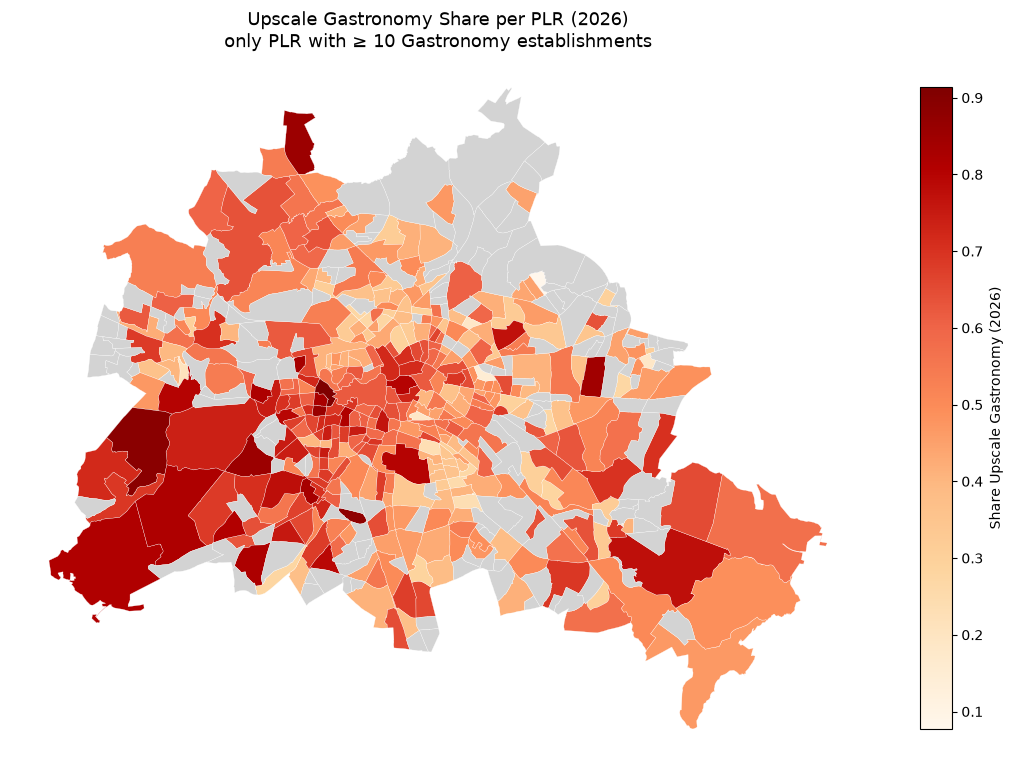

In [68]:
# 3) Join (inkl. n_gastro für die strengere Schwelle)
gdf = plr.merge(
    df[["plr_id", "com_upscale_share_level_2026", "com_n_gastro"]],
    on="plr_id", how="left")

# 4) nur Kieze mit >= 10 Gastrobetrieben einfärben (entfernt Kleine-Nenner-Artefakte)
MIN_GASTRO = 10
gdf["plot_val"] = gdf["com_upscale_share_level_2026"].where(
    gdf["com_n_gastro"] >= MIN_GASTRO)
print("eingefärbt:", gdf["plot_val"].notna().sum(), "von", len(gdf),
      f"(>= {MIN_GASTRO} Gastrobetriebe)")

# 5) Choroplethen-Karte
fig, ax = plt.subplots(figsize=(11, 11))
gdf.plot(column="plot_val", cmap="OrRd", legend=True,
         edgecolor="white", linewidth=0.2, ax=ax,
         legend_kwds={"label": "Share Upscale Gastronomy (2026)", "shrink": 0.6},
         missing_kwds={"color": "lightgrey", "label": f"< {MIN_GASTRO} Gastrobetriebe"})
ax.set_title(f"Upscale Gastronomy Share per PLR (2026)\nonly PLR with ≥ {MIN_GASTRO} Gastronomy establishments",
             fontsize=13)
ax.axis("off")
plt.tight_layout()
plt.show()

In [63]:
top = gdf[gdf["plot_val"].notna()].nlargest(10, "plot_val")
print(top[["plr_id", "plr_name", "plot_val"]].to_string(index=False))
# und wie viele Gastrobetriebe haben die? -> n_gastro dazuholen

  plr_id           plr_name  plot_val
04300622 Ernst-Reuter-Platz  0.913669
05400942          Alt-Gatow  0.887850
06100205            Südende  0.880000
04501041 George-Grosz-Platz  0.860000
04400729         Hundekehle  0.853659
12400721        Frohnau Ost  0.853659
10300731     Oberfeldstraße  0.842105
06100101        Fichtenberg  0.833333
04300517        Tegeler Weg  0.832558
04300624       Savignyplatz  0.828272


### Real Estate Dimension

coloured: 531 of 542


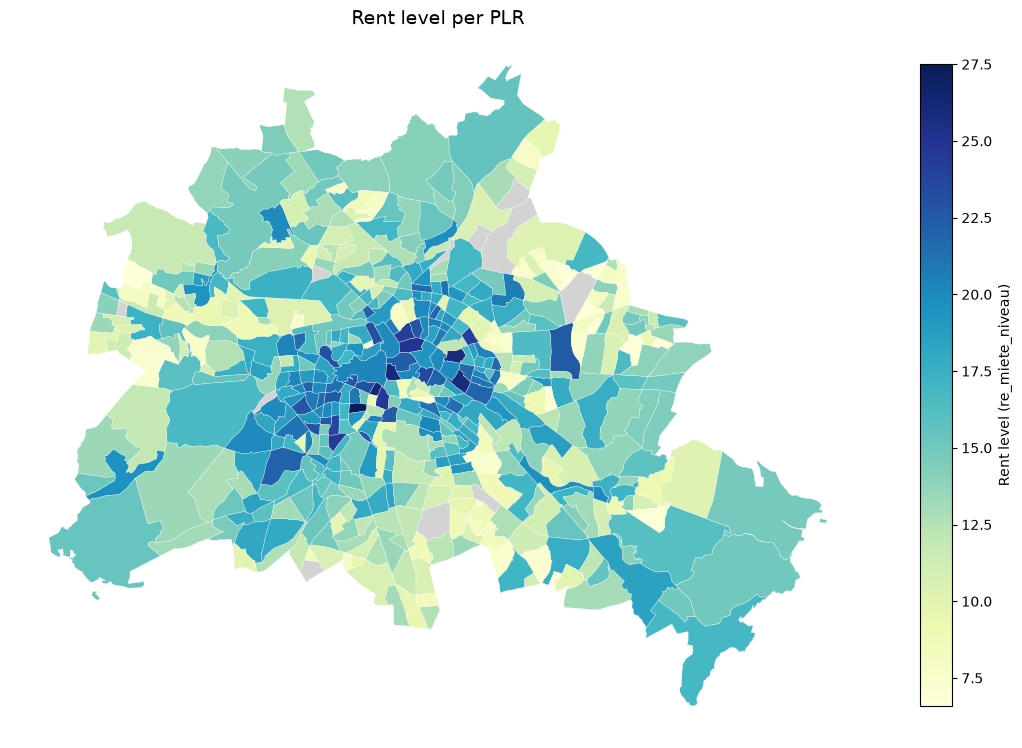

In [70]:
import matplotlib.pyplot as plt

COL = "re_miete_niveau"
# safety-check the column name
assert COL in df.columns, f"not found. re columns: {[c for c in df.columns if c.startswith('re_')]}"

# Join (plr already loaded, plr_id already zfill(8))
gdf = plr.merge(df[["plr_id", COL]], on="plr_id", how="left")
print("coloured:", gdf[COL].notna().sum(), "of", len(gdf))

# Choropleth — rent level >= 0, sequential scale
fig, ax = plt.subplots(figsize=(11, 11))
gdf.plot(column=COL, cmap="YlGnBu", legend=True,
         edgecolor="white", linewidth=0.2, ax=ax,
         legend_kwds={"label": "Rent level (re_miete_niveau)", "shrink": 0.6},
         missing_kwds={"color": "lightgrey", "label": "no value"})
ax.set_title("Rent level per PLR", fontsize=14)
ax.axis("off")
plt.tight_layout()
plt.show()

### Social Dimension

coloured: 535 of 542


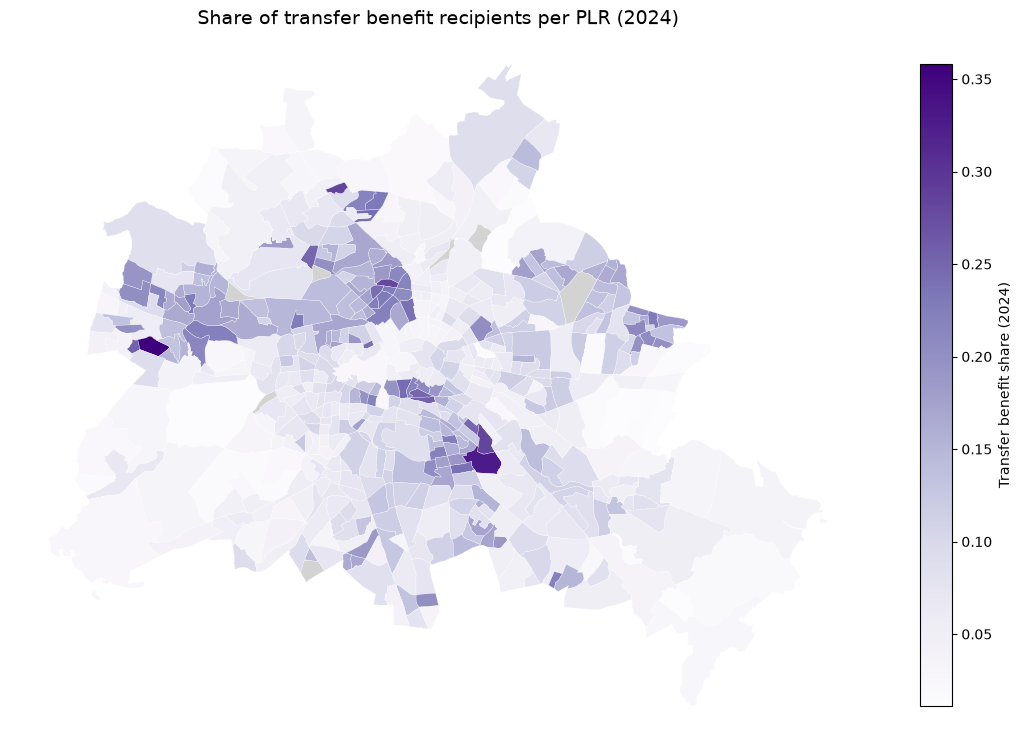

In [69]:
COL = "soc_transfer_benefit_share_2024"
# safety-check the column name
assert COL in df.columns, f"not found. soc columns: {[c for c in df.columns if 'soc' in c.lower()]}"

# Join (plr already loaded, plr_id already zfill(8))
gdf = plr.merge(df[["plr_id", COL]], on="plr_id", how="left")
print("coloured:", gdf[COL].notna().sum(), "of", len(gdf))

# Choropleth — share >= 0, sequential scale
fig, ax = plt.subplots(figsize=(11, 11))
gdf.plot(column=COL, cmap="Purples", legend=True,
         edgecolor="white", linewidth=0.2, ax=ax,
         legend_kwds={"label": "Transfer benefit share (2024)", "shrink": 0.6},
         missing_kwds={"color": "lightgrey", "label": "no value"})
ax.set_title("Share of transfer benefit recipients per PLR (2024)", fontsize=14)
ax.axis("off")
plt.tight_layout()
plt.show()

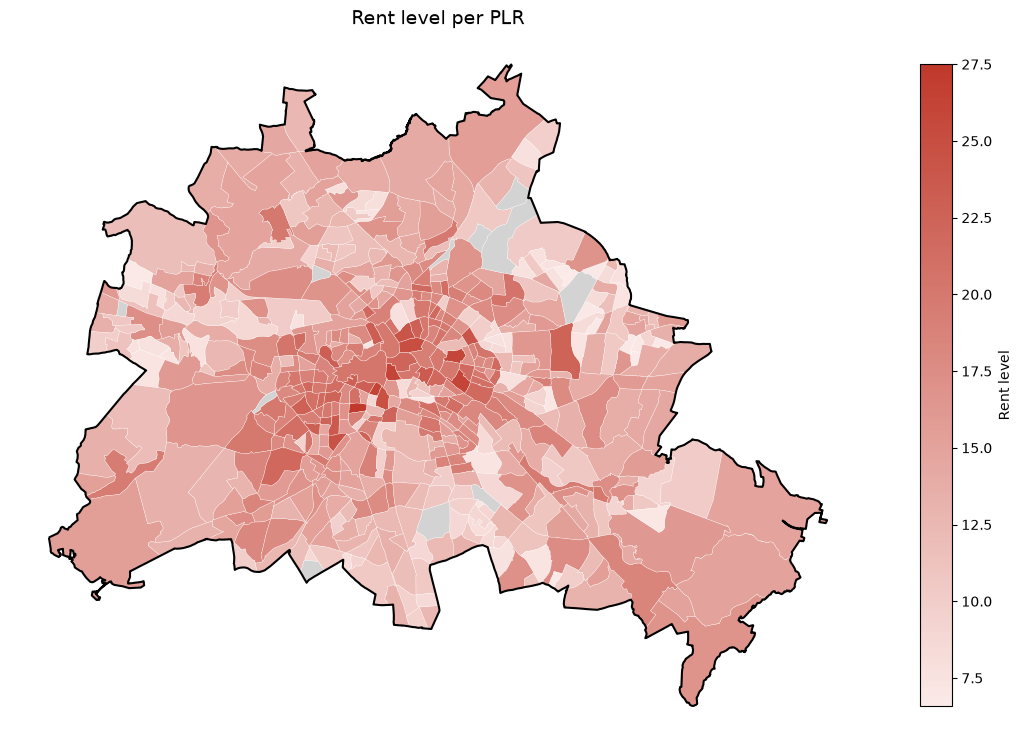

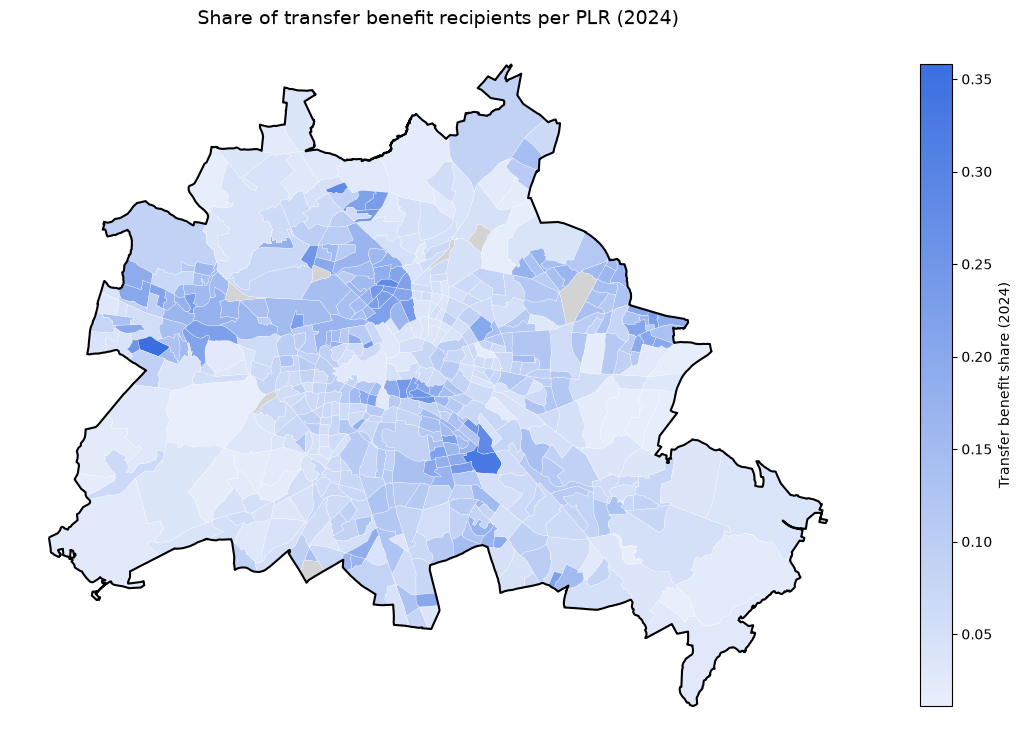

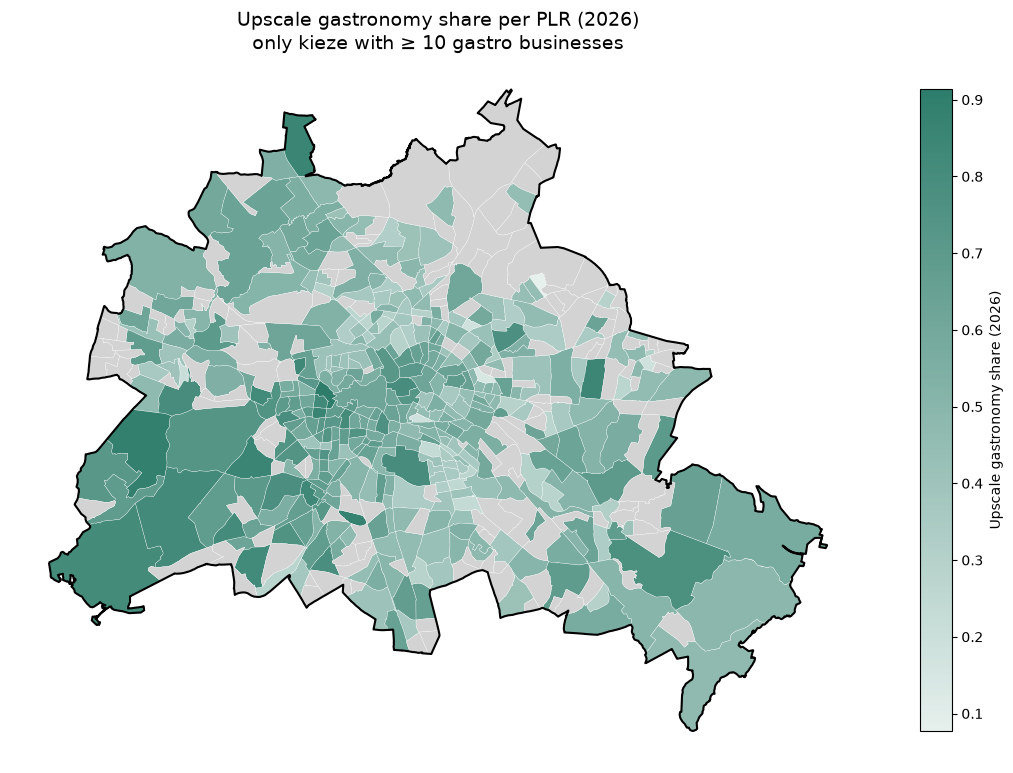

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# --- presentation colour scheme: light -> full gradients per dimension ---
cmap_rent     = LinearSegmentedColormap.from_list("rent",     ["#FBEAE8", "#C0392B"])  # red   = real estate
cmap_transfer = LinearSegmentedColormap.from_list("transfer", ["#E8EEFB", "#3B6FE0"])  # blue  = social
cmap_gastro   = LinearSegmentedColormap.from_list("gastro",   ["#E6F0ED", "#2E7D6B"])  # green = commercial

# Berlin outline: dissolve all PLR into one shape (compute once)
berlin_outline = plr.dissolve()

def plot_map(col, title, cmap, legend_label, min_gastro=None):
    assert col in df.columns, f"not found. matching: {[c for c in df.columns if col.split('_')[0] in c]}"
    g = plr.merge(df[["plr_id", col] + (["com_n_gastro"] if min_gastro else [])],
                  on="plr_id", how="left")
    plot_col = col
    if min_gastro:
        g["_plot"] = g[col].where(g["com_n_gastro"] >= min_gastro)
        plot_col = "_plot"

    fig, ax = plt.subplots(figsize=(11, 11))
    g.plot(column=plot_col, cmap=cmap, legend=True,
           edgecolor="white", linewidth=0.2, ax=ax,
           legend_kwds={"label": legend_label, "shrink": 0.6},
           missing_kwds={"color": "lightgrey", "label": "no value"})
    # black Berlin outline on top
    berlin_outline.boundary.plot(ax=ax, edgecolor="black", linewidth=1.5)
    ax.set_title(title, fontsize=14)
    ax.axis("off")
    plt.tight_layout()
    plt.show()

# --- 1) Real estate: rent level (RED) ---
plot_map("re_miete_niveau",
         "Rent level per PLR",
         cmap_rent, "Rent level")

# --- 2) Social: transfer benefit share (BLUE) ---
plot_map("soc_transfer_benefit_share_2024",
         "Share of transfer benefit recipients per PLR (2024)",
         cmap_transfer, "Transfer benefit share (2024)")

# --- 3) Commercial: upscale gastronomy share (GREEN), reliable kieze only ---
plot_map("com_upscale_share_level_2026",
         "Upscale gastronomy share per PLR (2026)\nonly kieze with ≥ 10 gastro businesses",
         cmap_gastro, "Upscale gastronomy share (2026)",
         min_gastro=10)

### Combinations